In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq

In [3]:
llm= ChatGroq(model="deepseek-r1-distill-llama-70b")

In [4]:
llm.invoke("What is the capital of France?")

AIMessage(content='<think>\n\n</think>\n\nThe capital of France is Paris.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 10, 'total_tokens': 22, 'completion_time': 0.054575937, 'prompt_time': 0.000197528, 'queue_time': 0.066969291, 'total_time': 0.054773465}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--598fb947-d3d0-4fe4-be99-d4bc4f75f214-0', usage_metadata={'input_tokens': 10, 'output_tokens': 12, 'total_tokens': 22})

In [5]:
from langchain_core.tools import tool

In [6]:
@tool
def multiply(x:int, y:int) -> int:
    """Multiplies two numbers."""
    
    return x * y

In [7]:
multiply

StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000017309C3AB60>)

In [8]:
multiply({"x":2, "y":3})

C:\Users\Satish\AppData\Local\Temp\ipykernel_16024\4161870413.py:1: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  multiply({"x":2, "y":3})


6

In [9]:
multiply.invoke({"x":10, "y":20})

200

In [10]:
multiply.description

'Multiplies two numbers.'

In [11]:
multiply.args

{'x': {'title': 'X', 'type': 'integer'},
 'y': {'title': 'Y', 'type': 'integer'}}

In [12]:
from langchain_community.tools import DuckDuckGoSearchRun, DuckDuckGoSearchResults

In [13]:
search= DuckDuckGoSearchRun()

In [14]:
search.description

'A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.'

In [15]:
search.invoke("What is the capital of France?")

'Paris, city and capital of France, located along the Seine River, in the north-central part of the country. Paris is one of the world\'s most important and attractive cities, famed for its gastronomy, haute couture, painting, literature, and intellectual community. Learn more about Paris in this article. Paris (French pronunciation: [paʁi] ) is the capital and largest city of France. With an estimated population of 2,048,472 residents in January 2025 in an area of more than 105 km2 (41 sq mi), Paris is the fourth-most populous city in the European Union and the 30th most densely populated city in the world in 2022. France: The capital of France is Paris. Paris is not only the political capital but also a major cultural and economic center. It is famous for landmarks such as the Eiffel Tower, Notre-Dame Cathedral, and the Louvre Museum. Germany: The capital of Germany is Berlin. Berlin is known for its rich history and cultural significance, including the ... Learn why Paris is the cap

In [16]:
search= DuckDuckGoSearchResults()

In [17]:
search.description

'A wrapper around Duck Duck Go Search. Useful for when you need to answer questions about current events. Input should be a search query.'

In [18]:
search.invoke("What is the capital of France?")

'snippet: Paris, city and capital of France, located along the Seine River, in the north-central part of the country. Paris is one of the world\'s most important and attractive cities, famed for its gastronomy, haute couture, painting, literature, and intellectual community. Learn more about Paris in this article., title: Paris | Definition, Map, Population, Facts, & History | Britannica, link: https://www.britannica.com/place/Paris, snippet: Paris (French pronunciation: [paʁi] ) is the capital and largest city of France. With an estimated population of 2,048,472 residents in January 2025 in an area of more than 105 km2 (41 sq mi), Paris is the fourth-most populous city in the European Union and the 30th most densely populated city in the world in 2022., title: Paris, Capital city of France - The World Countries, link: https://theworldcountries.com/geo/capital-city/Paris, snippet: France: The capital of France is Paris. Paris is not only the political capital but also a major cultural 

In [19]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [20]:
@tool
def search(query: str):
    """search the web for a query and return the results"""

    tavily= TavilySearchResults()
    result= tavily.invoke(query)
    return f"Result for {query} is: \n{result}"

In [21]:
search.description

'search the web for a query and return the results'

In [22]:
search.invoke({"query": "What is the capital of France?"})

'Result for What is the capital of France? is: \n[{\'title\': \'Paris facts: the capital of France in history\', \'url\': \'https://home.adelphi.edu/~ca19535/page%204.html\', \'content\': \'page 4\\n\\n===============\\n\\nHomeSpainSydneySan FranciscoParisLas VegasMaui\\n\\n Paris, France\\n\\nImage 1\\n\\nParis facts: Paris, the capital of France\\n---------------------------------------------\\n\\nParis is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants).\\n\\nParis has 2.234 million inhabitants end 2011. She is the core of Ile de France region (12 million people). [...] Before Paris, the capital of France was Lyon (under the Romans). Paris first became the capital of France in 508 under King Clovis. After centuries with no unique capital of France, Paris retrieved its status of capital of France under King Philippe Auguste, who reigned between 1180 and 1223. You can see remains of the Philippe August Paris walls in the passageway betwee

In [23]:
search.invoke("what is agentic ai?")

'Result for what is agentic ai? is: \n[{\'title\': \'Agentic AI - Wikipedia\', \'url\': \'https://en.wikipedia.org/wiki/Agentic_AI\', \'content\': \'Agentic AI is a class of artificial intelligence that focuses on autonomous systems that can make decisions and perform tasks without human intervention. The independent systems automatically respond to conditions, to produce process results. The field is closely linked to agentic automation, also known as agent-based process management systems, when applied to process automation. Applications include software development, customer support, cybersecurity and business intelligence. [...] The core concept of agentic AI is the use of _AI agents_ to perform automated tasks but without human intervention.( While robotic process automation (RPA) and AI agents can be programmed to automate specific tasks or support rule-based decisions, the rules are usually fixed.( Agentic AI operates independently, making decisions through continuous learning a

In [24]:
tools= [multiply, search]

In [25]:
tools

[StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000017309C3AB60>),
 StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001730F002D40>)]

In [26]:
llm_with_tools= llm.bind_tools(tools)

In [27]:
result= llm_with_tools.invoke("what is the current gdp of india?")

In [28]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'kc2567yjs', 'function': {'arguments': '{"query":"current GDP of India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 175, 'total_tokens': 310, 'completion_time': 0.560370915, 'prompt_time': 0.011803616, 'queue_time': 0.053538844, 'total_time': 0.572174531}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--19446f17-f73e-4974-bb37-fb62772666c7-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of India'}, 'id': 'kc2567yjs', 'type': 'tool_call'}], usage_metadata={'input_tokens': 175, 'output_tokens': 135, 'total_tokens': 310})

In [29]:
result.content

''

In [30]:
result.tool_calls

[{'name': 'search',
  'args': {'query': 'current GDP of India'},
  'id': 'kc2567yjs',
  'type': 'tool_call'}]

In [31]:
type(result.tool_calls)

list

In [32]:
result.tool_calls[0]

{'name': 'search',
 'args': {'query': 'current GDP of India'},
 'id': 'kc2567yjs',
 'type': 'tool_call'}

In [33]:
type(result.tool_calls[0])

dict

In [34]:
result.tool_calls[0]["name"]

'search'

In [35]:
result.tool_calls[0]["args"]

{'query': 'current GDP of India'}

In [36]:
tools

[StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000017309C3AB60>),
 StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001730F002D40>)]

In [37]:
{tool.name:tool for tool in tools}

{'multiply': StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000017309C3AB60>),
 'search': StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001730F002D40>)}

In [38]:
tool_mapping= {tool.name:tool for tool in tools}

In [39]:
tool_mapping

{'multiply': StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000017309C3AB60>),
 'search': StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001730F002D40>)}

In [40]:
tool_mapping["multiply"]

StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000017309C3AB60>)

In [41]:
tool_mapping["search"]

StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001730F002D40>)

In [42]:
tool_mapping["search"].args

{'query': {'title': 'Query', 'type': 'string'}}

In [43]:
tool_mapping["search"].description

'search the web for a query and return the results'

In [44]:
#manually i am passing here

tool_mapping["search"].invoke({"query": "What is the capital of india?"})

'Result for What is the capital of india? is: \n[{\'title\': \'What is the Capital of India? - Mappr\', \'url\': \'https://www.mappr.co/capital-cities/india/\', \'content\': \'What is the Capital of India?\\n=============================\\n\\nNew Delhi is the capital of India. A cosmopolitan city in South Asia, New Delhi is home to a diverse population that speaks many different languages and holds a wide variety of religious beliefs. The city of New Delhi is part of the larger Delhi Metro Area whose population is over 32 million, and it is well-known for its chaotic traffic and large crowds. [...] New Delhi was not always the capital of India. Prior to 1911, Calcutta was the capital city of the country. India was under British rule at this time, and it was decided to move the capital away from Calcutta due to the intense anti-colonial sentiments that existed there.\\n\\nImage 4: A bustling street with various vehicles, roadside billboards, and urban development on both sides.\\n\\nTra

In [45]:
result.tool_calls[0]

{'name': 'search',
 'args': {'query': 'current GDP of India'},
 'id': 'kc2567yjs',
 'type': 'tool_call'}

In [46]:
result.tool_calls[0]["name"]

'search'

In [47]:
result.tool_calls[0]["args"]

{'query': 'current GDP of India'}

In [48]:
tool_mapping[result.tool_calls[0]["name"]].invoke(result.tool_calls[0]["args"])

'Result for current GDP of India is: \n[{\'title\': \'World GDP Ranking 2025 List - ClearTax\', \'url\': \'https://cleartax.in/s/world-gdp-ranking-list\', \'content\': "India is currently ranked as the 4th largest economy globally in 2025, surpassing Japan to secure the 4th position among the world\'s top 10 largest economies, with a nominal GDP of $4.19 trillion in 2025. Moreover, the IMF forecasts that by 2027, India will overtake Germany to become the 3rd largest economy worldwide [...] With an estimated real GDP of Rs. 187.95 lakh crore in 2024-25, against the real GDP of Rs. 176.51 in 2023-24 generated by a population of over 1 billion, India is among the highest population-based economies in the world. Additionally, as per IMF projections, India\'s GDP grow is at 6.2% in 2024-25 and 2025-26.This means India\'s economic growth next fiscal year will be the fastest among major economies. Therefore, in the upcoming years, rising consumption and investments, both domestic and [...] ##

In [49]:
import operator
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage

In [50]:
class AgentState(TypedDict):
    """State for the agent."""
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [51]:
state= {"messages":["hi", "hello", "how are you?"]}

state

{'messages': ['hi', 'hello', 'how are you?']}

In [52]:
def invoke_model(state: AgentState):
    messages= state["messages"]
    question= messages[-1]
    response= llm_with_tools.invoke(question)

    return {"messages": [response]}

In [53]:
def router(state: AgentState):
    tool_calls= state["messages"][-1].tool_calls
    if len(tool_calls) > 0:
        return "tool" # key name
    else:
        return "end" # key name

In [73]:
def invoke_tool(state: AgentState):
    tool_details= state["messages"][-1].tool_calls

    if tool_details is None:
        return Exception("No tool calls found in the last message.")
    
    print(f"Selected tool: {tool_details[0]["name"]}")

    if tool_details[0]["name"] == "search":
        response= input(prompt= f"[yes/no] do you want to continue with this expensive web search")
        if response.lower() == 'no':
            print("web search discarded by the user. exiting gracefully")
            raise Exception("Web search discarded by the user.")
    
    response=tool_mapping[tool_details[0]["name"]].invoke(tool_details[0]["args"])

    return {"messages": [response]}

In [55]:
tools

[StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000017309C3AB60>),
 StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001730F002D40>)]

In [56]:
from langgraph.graph import StateGraph, START, END

In [74]:
graph= StateGraph(AgentState)

In [75]:
graph.add_node("ai_assistant", invoke_model)

eariler we were using the tool node from list of tool<br>
but now we have crated tool invoke(custom funtion)<br>
why we are doing it: as a user if we want to take a authority to which i need to give permission for execution<br>

In [76]:
graph.add_node("tool", invoke_tool)

In [77]:
graph.add_edge("tool", END)

In [78]:
graph.add_conditional_edges(
    "ai_assistant",
    router,
    {
        "tool": "tool", # with the key tool which value is associated <tool>
        "end": END
    }
)

In [79]:
graph.add_edge(START, "ai_assistant")

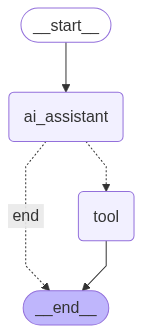

In [63]:
graph.compile()

In [80]:
app= graph.compile()

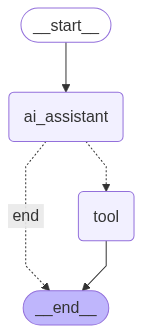

In [65]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [81]:
app.invoke({"messages": ["What is the multiplication of 10 and 20?"]})

Selected tool: multiply


{'messages': ['What is the multiplication of 10 and 20?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '16bqrpg46', 'function': {'arguments': '{"x":10,"y":20}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 177, 'total_tokens': 273, 'completion_time': 0.409597854, 'prompt_time': 0.104667311, 'queue_time': 3.625716789, 'total_time': 0.514265165}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--11becc89-6d01-44f0-bafc-625b348ba947-0', tool_calls=[{'name': 'multiply', 'args': {'x': 10, 'y': 20}, 'id': '16bqrpg46', 'type': 'tool_call'}], usage_metadata={'input_tokens': 177, 'output_tokens': 96, 'total_tokens': 273}),
  200]}

##### "[yes/no] do you want to continue with this expensive web search"
user_input= yes

In [82]:
app.invoke({"messages": ["What is the current gdp of the india?"]})

Selected tool: search


{'messages': ['What is the current gdp of the india?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8p0gjses8', 'function': {'arguments': '{"query":"current GDP of India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_tokens': 176, 'total_tokens': 305, 'completion_time': 0.550502441, 'prompt_time': 0.012063178, 'queue_time': 0.053941302, 'total_time': 0.562565619}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--11c42451-6539-43fa-ab9b-bc23feb578e2-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of India'}, 'id': '8p0gjses8', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 129, 'total_tokens': 305}),
  'Result for current GDP of India is: \n[{\'title\': \'India - GDP, PPP (current International $) - 2025 Data 2026 Forecast ...\', \'url\': \'https://tradingec

##### "[yes/no] do you want to continue with this expensive web search"
user_input= no

In [68]:
app.invoke({"messages": ["What is the current gdp of the india?"]})

Selected tool: search
web search discarded by the user. exiting gracefully


Exception: Web search discarded by the user.

##### "[yes/no] do you want to continue with this expensive web search"
user_input= YES

In [83]:
app.invoke({"messages": ["What is the current weather in india delhi?"]})

Selected tool: search


{'messages': ['What is the current weather in india delhi?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qhtrw1gzh', 'function': {'arguments': '{"query":"current weather in Delhi India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 138, 'prompt_tokens': 176, 'total_tokens': 314, 'completion_time': 0.630984124, 'prompt_time': 0.016416237, 'queue_time': 6.699632054, 'total_time': 0.647400361}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--52d3125f-31d9-4d30-ae22-305fe38c8668-0', tool_calls=[{'name': 'search', 'args': {'query': 'current weather in Delhi India'}, 'id': 'qhtrw1gzh', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 138, 'total_tokens': 314}),
  'Result for current weather in Delhi India is: \n[{\'title\': \'Delhi-NCR Weather Update: Rain, High Humidity Grip Region ... - Onei

##### "[yes/no] do you want to continue with this expensive web search"
user_input= NO

In [70]:
app.invoke({"messages": ["What is the current weather in india delhi?"]})

Selected tool: search
web search discarded by the user. exiting gracefully


Exception: Web search discarded by the user.

In [84]:
app.invoke({"messages": ["what is a latest news of kolkata?"]})

Selected tool: search


{'messages': ['what is a latest news of kolkata?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'n1bkpfbb4', 'function': {'arguments': '{"query":"latest news Kolkata"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 169, 'prompt_tokens': 175, 'total_tokens': 344, 'completion_time': 0.662823748, 'prompt_time': 0.010993044, 'queue_time': 0.057535786, 'total_time': 0.673816792}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--76ce2826-af24-4956-9d69-5e0cd52139f7-0', tool_calls=[{'name': 'search', 'args': {'query': 'latest news Kolkata'}, 'id': 'n1bkpfbb4', 'type': 'tool_call'}], usage_metadata={'input_tokens': 175, 'output_tokens': 169, 'total_tokens': 344}),
  'Result for latest news Kolkata is: \n[{\'title\': \'Kolkata News, Latest Kolkata News Headlines & Live Updates, Breaking ...\', \'url\': \'https://m.timesofindia.c

In [85]:
app.invoke({"messages": ["what is a current weathter in newyork city?"]})

Selected tool: search


{'messages': ['what is a current weathter in newyork city?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'e3hg58e6s', 'function': {'arguments': '{"query":"current weather in New York City"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 214, 'prompt_tokens': 180, 'total_tokens': 394, 'completion_time': 0.870432505, 'prompt_time': 0.011598735, 'queue_time': 0.054854525, 'total_time': 0.88203124}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--00a8d91c-a894-427f-8e5a-74dab8912a80-0', tool_calls=[{'name': 'search', 'args': {'query': 'current weather in New York City'}, 'id': 'e3hg58e6s', 'type': 'tool_call'}], usage_metadata={'input_tokens': 180, 'output_tokens': 214, 'total_tokens': 394}),
  'Result for current weather in New York City is: \n[{\'title\': \'United States weather forecast for Sunday, 29 June 2025\', \'ur

### Langgraph inbuilt human in loop